# Tutorial on using masking functions for MSA Transformer
# Getting Started
See the paper by [Rao et al 2021](https://proceedings.mlr.press/v139/rao21a.html) for details on the model

In this tutorial, I will show how to use the functions I have written to get probabilities of different paths to the same inital and final sequences. (I have recently adapted some of the functions so if you are getting errors, no problem just let me know)

## Setup

Please see this [link to installation instructions](https://github.com/facebookresearch/esm) for getting dependencies and installing esm

## Imports

In [1]:
from importlib import reload
import main_simple as ms #import evolution_with_context
import helper_functions as hp
import torch
import esm
import numpy as np
import time

## 1. Loading 
The model will be the msa transformer. The alphabet tells us how to translate a fasta file into usable data for the transformer

In [19]:
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
protein = 'DHFR'
file_name = f'{protein}_data/hhfilter_alignment_split_context_55_percent.fasta'
#protein = 'p53'
#file_name = f'{protein}_data/msa_p53_unimsa.fa'


## 2. Running the paths calculation

In [20]:
# Input to get data out
data = hp.read_fasta_to_data(file_name)
batch_converter = alphabet.get_batch_converter()
batch_labels, batch_strs, batch_tokens= batch_converter(data)
gpu=True
# Checks to make sure you have a gpu available (cuda))
device = torch.device("cuda:0" if (torch.cuda.is_available()) and gpu else "cpu")
print(f'Device is {device}')

# Puts everything on that device
model.to(device)
batch_tokens = batch_tokens.to(device)


Device is cuda:0


In [48]:
num_mask = 5 # Keep 5 for now, let's see what it looks like
iters = 15 # This is the number of paths. It is taking forever so again leave at 15
num_pairs = 6 # This is just for the number of sequences to look at. Again lets leave at 20 but see how it goes

In [49]:
reload(ms)
prob_paths, prob_all_at_once, starting_seqs, ending_seqs = ms.diff_paths_random(batch_tokens, model, alphabet, num_mask=num_mask, num_pairs=num_pairs, iters=iters)

batch token shape is torch.Size([1, 956, 159])


100%|██████████| 6/6 [08:52<00:00, 88.72s/it]


In [50]:
filepath = 'output_DHFR/' # path to the folder to save the outputs

# Saving the outputs of the different paths
np.save(f'{filepath}prob_paths_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs', prob_paths)
np.save(f'{filepath}prob_at_once_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs', prob_all_at_once)
np.save(f'{filepath}starting_seqs_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs', starting_seqs)
np.save(f'{filepath}ending_seqs_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs', ending_seqs)

# to load the files about you would say arr = np.load('filename') *** filename should end in .npy


## Understanding the ouput


In [51]:
# Look at the shapes
prob_paths.shape, prob_all_at_once.shape, starting_seqs.shape, ending_seqs.shape

(torch.Size([6, 15]),
 torch.Size([6]),
 torch.Size([6, 159]),
 torch.Size([6, 159]))

In [106]:
# Below should have numbers similarish but not the same. It is the probability if you mask all at once compared to all the paths
prob_all_at_once[0], prob_paths[0] 

(-28.051529,
 tensor([-27.7520, -28.1672, -27.7893, -27.7540, -27.8780, -28.0857, -27.8287,
         -28.0706, -28.0841, -27.7573, -27.6868, -27.7146, -28.0517, -28.0998,
         -28.1672]))

In [70]:
starting_seqs[0], ending_seqs[0] # These should be 5 positions different

(array([ 0., 20., 12., 15., 20.,  7.,  7., 23.,  8., 13., 15., 19.,  6.,
         6., 12.,  6.,  4., 17., 17., 15.,  4., 14., 22., 21., 23., 14.,
         9., 13.,  4.,  9., 19., 18., 15.,  9., 16., 11.,  4., 19., 15.,
        11.,  7.,  7., 20.,  6., 10., 15., 11., 18.,  9.,  8.,  4., 14.,
        21.,  6.,  4., 14.,  4., 10.,  9., 17.,  7.,  7.,  4., 11., 17.,
         4., 18., 15., 14., 17., 23., 17., 15., 11.,  4., 19., 11., 17.,
         5., 16.,  6.,  4.,  4., 16., 19., 11.,  9., 11., 15., 10., 13.,
        12., 22., 12., 12.,  6.,  6., 15.,  8., 12., 19., 13., 16.,  4.,
         4., 14., 18.,  7.,  9.,  9., 12., 21., 21., 11.,  7., 12.,  8.,
         6.,  9., 19.,  9., 23., 13., 11., 18., 20., 13.,  7., 11., 16.,
        22.,  8., 13., 22.,  9.,  4., 15.,  9., 11., 15., 30., 30., 30.,
        30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
        30., 30., 30.], dtype=float32),
 array([ 7., 20., 12., 15., 20.,  7.,  7., 23.,  8., 13., 15., 19.,  6.,
         6.

## 3. Visualizing the results

There are a few ways I can imagine doing this
- Take the differences between all the paths and histogram it
- Compared the distances like var/mean
- I think maybe a boxplot of the variance of the path difference/mean of the probabilities

In [54]:
filepath = 'output_DHFR/'
num_mask = 5 # Keep 5 for now, let's see what it looks like
iters = 15 # This is the number of paths. It is taking forever so again leave at 15
num_pairs = 6 # This is just for the number of sequences to look at. Again lets leave at 20 but see how it goes

# Load the data to analyze
prob_paths = np.load(f'{filepath}prob_paths_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs.npy')
prob_all_at_once = np.load(f'{filepath}prob_at_once_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs.npy')
starting_seqs = np.load(f'{filepath}starting_seqs_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs.npy')
ending_seqs = np.load(f'{filepath}ending_seqs_{iters}_iters_{num_mask}_masked_{num_pairs}_pairs.npy')

In [58]:
# Don't overthink this. New is just an array containing the differences between all the path probabilities 


prob_paths = torch.tensor(prob_paths)
t_row = prob_paths.unsqueeze(2) # This has shape n_seq, n_iters, 1 (So n_seq planes with n_iters rows, 1 col)
t_col = prob_paths.unsqueeze(1) # This has shape n_seq, 1, n_iters (n_seq planes with 1 row and n_iters cols)
# When you subtract these it will broadcast the col one over so that you get the diff of all the values from each other for each plane
diff = torch.abs(t_row - t_col) # Size num_seq, num_iters, num_iters

# Create a diagonal mask
diagonal_mask = torch.eye(diff.size(1), dtype=torch.bool)

# Invert the mask to get non-diagonal elements
non_diagonal_mask = ~diagonal_mask

# Expand the mask to 3D to match the shape of the difference matrices
expanded_mask = non_diagonal_mask.unsqueeze(0).expand_as(diff)

# Apply the expanded mask to get non-diagonal elements
non_diagonal_elements = diff[expanded_mask]


new = non_diagonal_elements.reshape(prob_paths.size(0), prob_paths.size(1) * (prob_paths.size(1)-1)) 
new.shape

/scratch/local/30368308/ipykernel_2352224/3552609532.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prob_paths = torch.tensor(prob_paths)


torch.Size([6, 210])

[0 3 5 1 4]
210 208
210 210
210 202
210 208


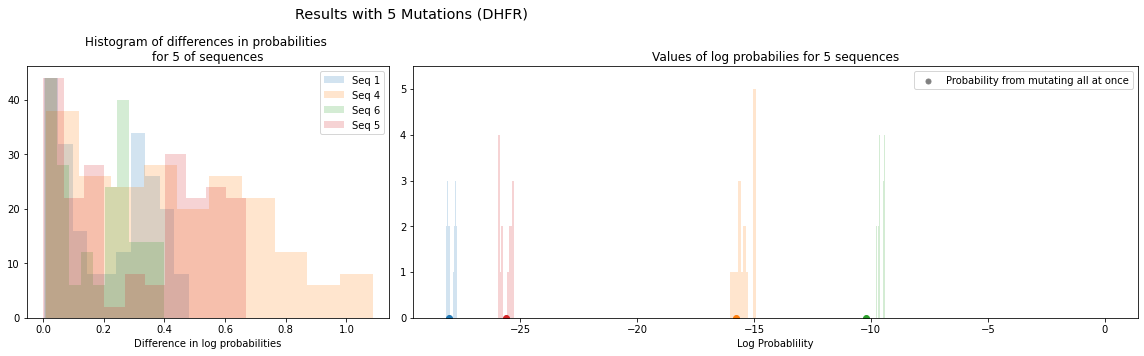

In [ ]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5))
N=5
# Define the grid layout
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])  # This makes the second column twice as wide as the first

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # First row, first column
ax2 = fig.add_subplot(gs[0, 1])  # Second row, first column

idx = np.random.choice(new.shape[0], size=5, replace=False, p=None)
print(idx)

for i in idx:#range(N):
    
    #arr = prob_product.cpu()
    #print(np.isnan(new[i].numpy()))
    if(np.any(np.isnan(new[i].numpy()))):
       continue
    arr = new[i].cpu().numpy().flatten()

    print(len(arr), len(arr[np.nonzero(arr)]))
    ax1.hist(arr[np.nonzero(arr)], alpha = 0.2, label=f'Seq {i+1}')
ax1.set_title(f'Histogram of differences in probabilities \nfor {N} of sequences')
ax1.legend()
ax1.set_xlabel('Difference in log probabilities')   
    
for i in idx:#range(N):
    if(np.any(np.isnan(new[i].numpy()))):
       continue
    plt.hist(prob_paths[i].cpu().numpy(), alpha = 0.2)
    plt.scatter(prob_all_at_once[i], 0)
#ax2.legend()
ax2.set_xlabel('Log Probablility')
ax2.set_title('Values of log probabilies for 5 sequences')
plt.scatter(0,-5,s=25,label='Probability from mutating all at once', c = 'grey')
ax2.legend()
ax2.set_ylim(bottom=0)
fig.suptitle(f'Results with {num_mask} Mutations (DHFR)', x = 0.36,fontsize='x-large')
plt.tight_layout()
plt.savefig(f'diff_and_log_prob_{num_mask}_muts_{protein}_near_zero')

torch.Size([6])


Text(0.5, 0, '$\\sigma$')

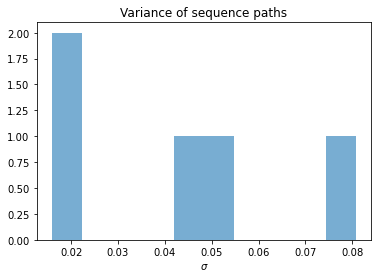

In [185]:
import matplotlib.pyplot as plt
#### I wouldn't choose this one. I would pick the two 

var = new.var(dim=1)
mean = prob_paths.mean(dim=1)
print(var.shape)

plt.hist(var.numpy(), alpha = .6)
plt.title('Variance of sequence paths')
plt.xlabel('$\sigma$')

Text(0.5, 0, 'Difference in log probabilities')

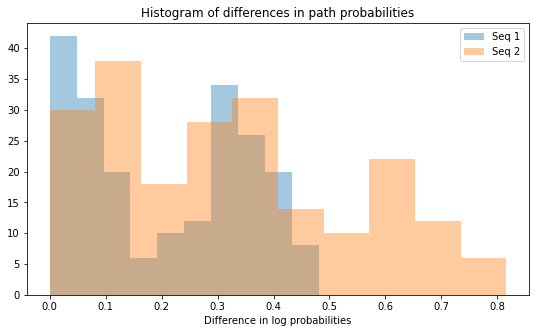

In [ ]:
plt.figure(figsize=(9,5))
a = (new.transpose(0,1)/mean).transpose(0,1)
plt.hist(new[0].numpy(), alpha = 0.4, label='Seq 1')
plt.hist(new[2].numpy(), alpha = 0.4, label = 'Seq 2')
plt.title('Histogram of differences in path probabilities')
plt.legend()
plt.xlabel('Difference in log probabilities')

torch.Size([6, 210])


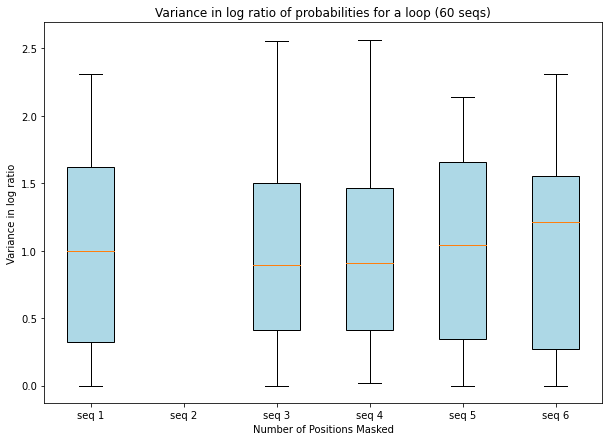

In [ ]:
fig = plt.figure(figsize =(10, 7))
ax = fig.add_subplot(111)
print(new.shape)
normalized_diff = (new.transpose(0,1)/mean).transpose(0,1)
bp = ax.boxplot(normalized_diff, positions=np.arange(1, 7), showfliers=True, patch_artist = True, zorder=-1)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
tick_labels = []
for i in range(6):
    tick_labels.append(f'seq {i+1}')
ax.set_xticks(np.arange(6)+1)
ax.set_xticklabels(tick_labels)
ax.set_xlabel('Number of Positions Masked')
plt.title('Variance in log ratio of probabilities for a loop (60 seqs)')
ax.set_ylabel('Variance in log ratio')
plt.savefig('figs/Variance_in_loops_blox_plot')

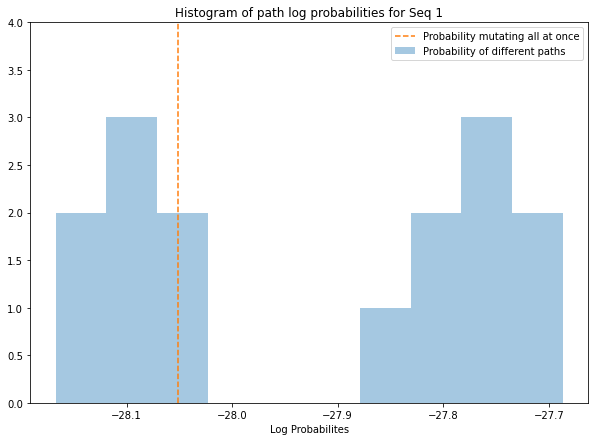

In [155]:
plt.figure(figsize=(10,7))
hist = plt.hist(prob_paths[0].numpy(), alpha = 0.4, label ='Probability of different paths')
plt.plot([prob_all_at_once[0], prob_all_at_once[0]], [0,hist[0].max()+1.2], '--', label = 'Probability mutating all at once')
plt.ylim([0,hist[0].max()+1])
plt.title('Histogram of path log probabilities for Seq 1')
plt.xlabel('Log Probabilites')
plt.legend()

## VISUALIZING THE RESULTS (OG)-don't use

In [39]:
import matplotlib.pyplot as plt

This will just help show what the differences between paths are. We take N of the sequences for visualization purposes

The first plot shows the differences in probabilities between the paths

Text(0.5, 0, 'Difference in log probabilities')

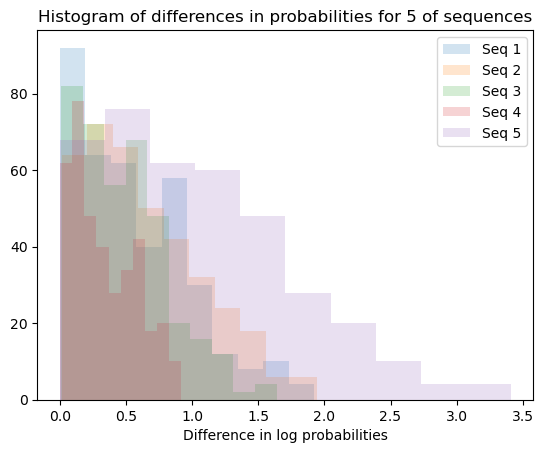

In [52]:
file_path = f'output_path_dependence/DHFR/prob_product_{num_mask}_mut_rand.npy'
prob_product = torch.from_numpy(np.load(file_path)).cuda()

N=5
fig, ax = plt.subplots(1) 
t_row = prob_product.unsqueeze(2) # This has shape n_seq, n_iters, 1 (So n_seq planes with n_iters rows, 1 col)
t_col = prob_product.unsqueeze(1) # This has shape n_seq, 1, n_iters (n_seq planes with 1 row and n_iters cols)
# When you subtract these it will broadcast the col one over so that you get the diff of all the values from each other for each plane
diff = torch.abs(t_row - t_col) # Size num_seq, num_iters, num_iters

# Create a diagonal mask
diagonal_mask = torch.eye(diff.size(1), dtype=torch.bool)

# Invert the mask to get non-diagonal elements
non_diagonal_mask = ~diagonal_mask

# Expand the mask to 3D to match the shape of the difference matrices
expanded_mask = non_diagonal_mask.unsqueeze(0).expand_as(diff)

# Apply the expanded mask to get non-diagonal elements
non_diagonal_elements = diff[expanded_mask]

#print(non_diagonal_elements.shape)


new = non_diagonal_elements.reshape(prob_product.size(0), prob_product.size(1) * (prob_product.size(1)-1)) 
#print('new shape', new.shape)

for i in range(N):
    #arr = prob_product.cpu()
    arr = new[i].cpu().numpy().flatten()

    #print(len(arr), len(arr[np.nonzero(arr)]))
    ax.hist(arr[np.nonzero(arr)], alpha = 0.2, label=f'Seq {i+1}')

plt.title(f'Histogram of differences in probabilities for {N} of sequences')
plt.legend()
plt.xlabel('Difference in log probabilities')

The second shows the actual values of the probabilites for each path

Text(0.5, 1.0, 'Values of log probabilies for 5 sequences')

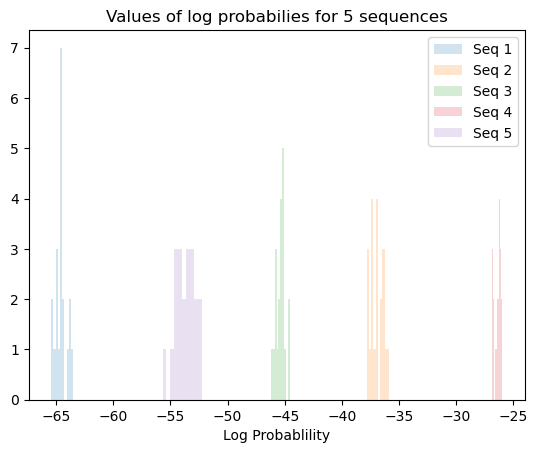

In [53]:
N=5

for i in range(N):
    plt.hist(prob_product[i].cpu(), alpha = 0.2, label=f'Seq {i+1}')
plt.legend()
plt.xlabel('Log Probablility')
plt.title('Values of log probabilies for 5 sequences')

Here they are compared. What is important to see is that the differences are close to the variance which means it does pretty well

380 380
380 380
380 380
380 380
380 380


Text(0.5, 1.0, 'Values of log probabilies for 5 sequences')

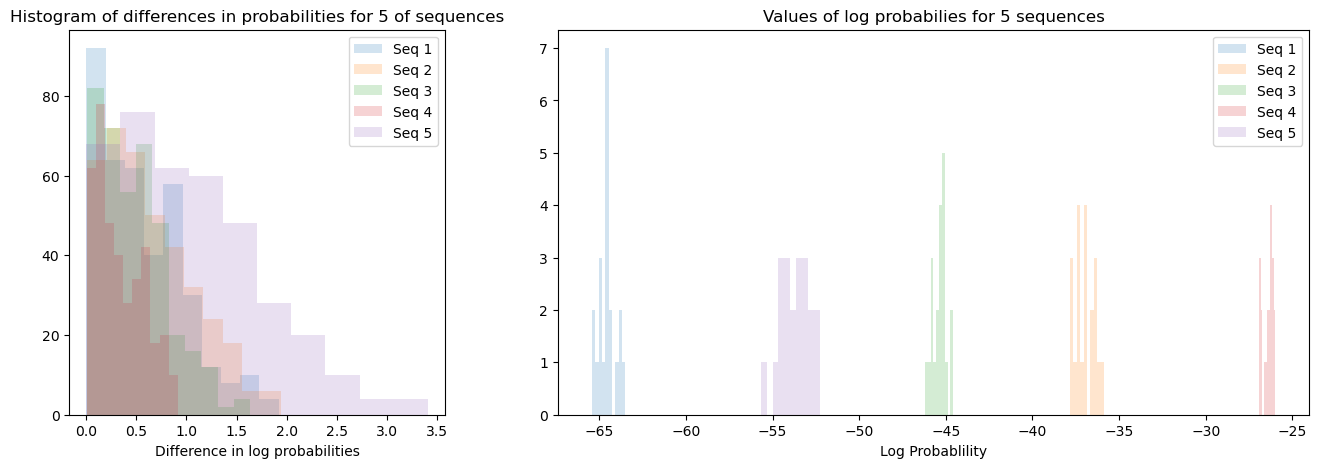

In [54]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5))

# Define the grid layout
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])  # This makes the second column twice as wide as the first

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # First row, first column
ax2 = fig.add_subplot(gs[0, 1])  # Second row, first column

for i in range(N):
    #arr = prob_product.cpu()
    arr = new[i].cpu().numpy().flatten()

    print(len(arr), len(arr[np.nonzero(arr)]))
    ax1.hist(arr[np.nonzero(arr)], alpha = 0.2, label=f'Seq {i+1}')
ax1.set_title(f'Histogram of differences in probabilities for {N} of sequences')
ax1.legend()
ax1.set_xlabel('Difference in log probabilities')   
    
for i in range(N):
    plt.hist(prob_product[i].cpu(), alpha = 0.2, label=f'Seq {i+1}')
ax2.legend()
ax2.set_xlabel('Log Probablility')
ax2.set_title('Values of log probabilies for 5 sequences')
